Fountain Optimization Analysis
===============================
This notebook visualizes the results of multi-model fountain sequence design,
demonstrating why the optimization was ultimately unsuccessful.

Background
----------
Fountain structures are contact patterns visible as elevated signal along the
antidiagonal of a Hi-C contact map, reflecting convergent chromatin interactions.
We attempted to design synthetic DNA sequences that induce fountain-like structures
by optimizing against a cone-shaped antidiagonal mask applied to predictions from
4 Akita v2 ensemble models (models 0–3) simultaneously.

Why the optimization fails
--------------------------
The 4 models used during optimization (models 0–3) show visible fountain-like
enrichment in the designed sequences — the optimizer successfully minimizes the
loss with respect to those models. However, the 4 held-out validation models
(models 4–7), which were not part of the optimization, do not exhibit
fountain-like structures. This lack of generalization across the ensemble
precludes visual validation of the designs and suggests the optimizer is
exploiting model-specific biases rather than learning a sequence grammar that
robustly encodes fountain structure.

This is in contrast to successful boundary and dot designs, where both
optimization and held-out models show consistent enrichment.

## Imports

In [1]:
import os
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))
sys.path.insert(0, "/home1/smaruj/ledidi/ledidi/")
sys.path.insert(0, os.path.abspath("/home1/smaruj/ledidi_akita/"))

from akita.model import SeqNN
from utils.data_utils import from_upper_triu
from utils.optimization_utils import build_stem, strength_tag

## Config

In [2]:
# Edit these to match the optimization run you want to inspect.
# FOLD and RUN_NAME must match what was used in run_fountain_design.py.
# N_EXAMPLES controls how many windows are shown in the final plot.

FOLD              = 0
FOUNTAIN_STRENGTH = 0.5
TAG               = strength_tag(FOUNTAIN_STRENGTH)
RUN_NAME          = "results"
N_EXAMPLES        = 5
ALL_MODELS        = 8
OPT_MODELS        = 4    # models 0–3 used in optimisation

_PROJ = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita"

SEQ_BASE_DIR = (
    "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/"
    "analysis/flat_regions"
)
FOUNTAIN_DIR   = f"{_PROJ}/optimizations/fountains"
RESULTS_DIR    = f"{FOUNTAIN_DIR}/{RUN_NAME}/fold{FOLD}"
MASK_PATH      = f"{_PROJ}/optimizations/feature_masks/fountain_{TAG}_mask.pt"

TSV_PATH       = (
    f"{SEQ_BASE_DIR}/mouse_flat_regions_chrom_states_tsv/"
    f"fold{FOLD}_selected_genomic_windows_centered_chrom_states.tsv"
)
MODEL_PATH_PATTERN = (
    "/home1/smaruj/pytorch_akita/models/trained_from_scratch/Vian2018_Bcells/checkpoints/"
    "Akita_v2_mouse_Vian2018_Bcells_model{model_idx}_from_scratch.pth"
)

#  ── Architecture constants ────────────────────────────────────────────────────
CENTER_BIN_MAP   = 256
N_EDIT_BINS      = 50
CONTEXT_BINS     = 5
SPLICE_BUFFER    = 2
CROPPING_APPLIED = 64
MAP_SIZE         = 512
NUM_DIAGS        = 2

# ── Visualisation ─────────────────────────────────────────────────────────────
VMIN, VMAX = -0.6, 0.6
CMAP       = 'RdBu_r'

## Load models and mask

All 8 models are loaded upfront:   
- models 0–3  were used during optimization (optimization models)   
- models 4–7  are held-out validation models not seen during optimization    

The fountain mask contains upper-tri indices of the antidiagonal cone region used both as the optimization target and for computing fountain scores.

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

models = []
for model_idx in range(ALL_MODELS):
    m = SeqNN()
    m.load_state_dict(torch.load(
        MODEL_PATH_PATTERN.format(model_idx=model_idx),
        map_location=device, weights_only=True,
    ))
    m.to(device).eval()
    models.append(m)
    print(f"Model {model_idx} loaded")

fountain_mask = torch.load(MASK_PATH, weights_only=True)   # (K,) upper-tri indices
print(f"Fountain mask: {fountain_mask.shape[0]} positions")

Device: cuda:0
Model 0 loaded
Model 1 loaded
Model 2 loaded
Model 3 loaded
Model 4 loaded
Model 5 loaded
Model 6 loaded
Model 7 loaded
Fountain mask: 32693 positions


## Fountain score

The fountain score is defined as the mean predicted signal within the
antidiagonal cone mask region of the upper-triangular contact map vector.
Higher scores indicate stronger predicted fountain-like enrichment.
Scores are computed for both before and after maps to quantify the
optimization effect per model.

In [4]:
def fountain_score(y: torch.Tensor, mask: torch.Tensor) -> float:
    """Average predicted signal within the fountain mask region.

    Parameters
    ----------
    y    : (N_triu,) upper-tri vector (CPU tensor or numpy array)
    mask : (K,) LongTensor of upper-tri indices

    Returns
    -------
    float : mean signal within the masked positions
    """
    if not isinstance(y, torch.Tensor):
        y = torch.tensor(y)
    return y[mask].mean().item()

## Load TSV and select N_EXAMPLES windows

Windows are filtered to those that have a generated sequence saved on disk,
meaning the optimization run completed for them. The first N_EXAMPLES
available windows are selected for visualization.

In [5]:
import pandas as pd

df = pd.read_csv(TSV_PATH, sep="\t")
print(f"Total windows in fold {FOLD}: {len(df)}")

# Keep only windows that have a generated sequence saved
df["stem"] = df.apply(
    lambda r: build_stem(r["chrom"], int(r["centered_start"]), int(r["centered_end"])),
    axis=1,
)
df["gen_seq_path"] = df["stem"].apply(
    lambda s: os.path.join(RESULTS_DIR, f"{s}_gen_seq.pt")
)
df_available = df[df["gen_seq_path"].apply(os.path.exists)].reset_index(drop=True)
print(f"Windows with generated sequences: {len(df_available)}")

# examples = df_available.head(N_EXAMPLES)
examples = df_available[10:15]

Total windows in fold 0: 24
Windows with generated sequences: 24


## Compute predictions and scores

For each example window:    
    - "before" prediction: model 0 on the original unedited sequence    
    - "after" predictions: all 8 models on the sequence with the designed edits applied to the central 50-bin (102,400 bp) editable region    
    

In [6]:
# Edit bp coordinates derived directly from constants (no Semifreddo needed)
EDIT_BP_START = (CENTER_BIN_MAP - N_EDIT_BINS // 2 + CROPPING_APPLIED) * 2048
EDIT_BP_END   = EDIT_BP_START + N_EDIT_BINS * 2048

results = []   # list of dicts, one per window

for _, row in examples.iterrows():
    stem = row["stem"]
    print(f"Processing {stem} ...", end=" ")

    X = torch.load(
        f"{SEQ_BASE_DIR}/mouse_sequences/fold{FOLD}/{stem}_X.pt",
        weights_only=True,
    ).to(device)

    gen_seq = torch.load(row["gen_seq_path"], weights_only=True).to(device)

    X_gen = X.clone()
    X_gen[:, :, EDIT_BP_START:EDIT_BP_END] = gen_seq

    with torch.no_grad():
        y_before = models[0](X).squeeze().cpu()
        y_after  = [m(X_gen).squeeze().cpu() for m in models]

    results.append({"stem": stem, "y_before": y_before, "y_after": y_after})
    print("done")

Processing chr4_104042496_105353216 ... 

/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


done
Processing chr4_94752768_96063488 ... done
Processing chr5_96686080_97996800 ... done
Processing chr5_48883712_50194432 ... done
Processing chr5_36857856_38168576 ... done


## Plot — N_EXAMPLES × (before + 8 after) maps with fountain scores

Layout: each row is one genomic window; columns are:     
    col 0        — before optimization (model 0, flat region baseline)     
    cols 1–4     — after optimization, models 0–3 (used in optimization)    
    cols 5–8     — after optimization, models 4–7 (held-out validation)   

The fountain score (mean signal in mask region) is shown below each map.
Optimization models typically show score increases; held-out models do not,
illustrating the failure to generalize across the ensemble.

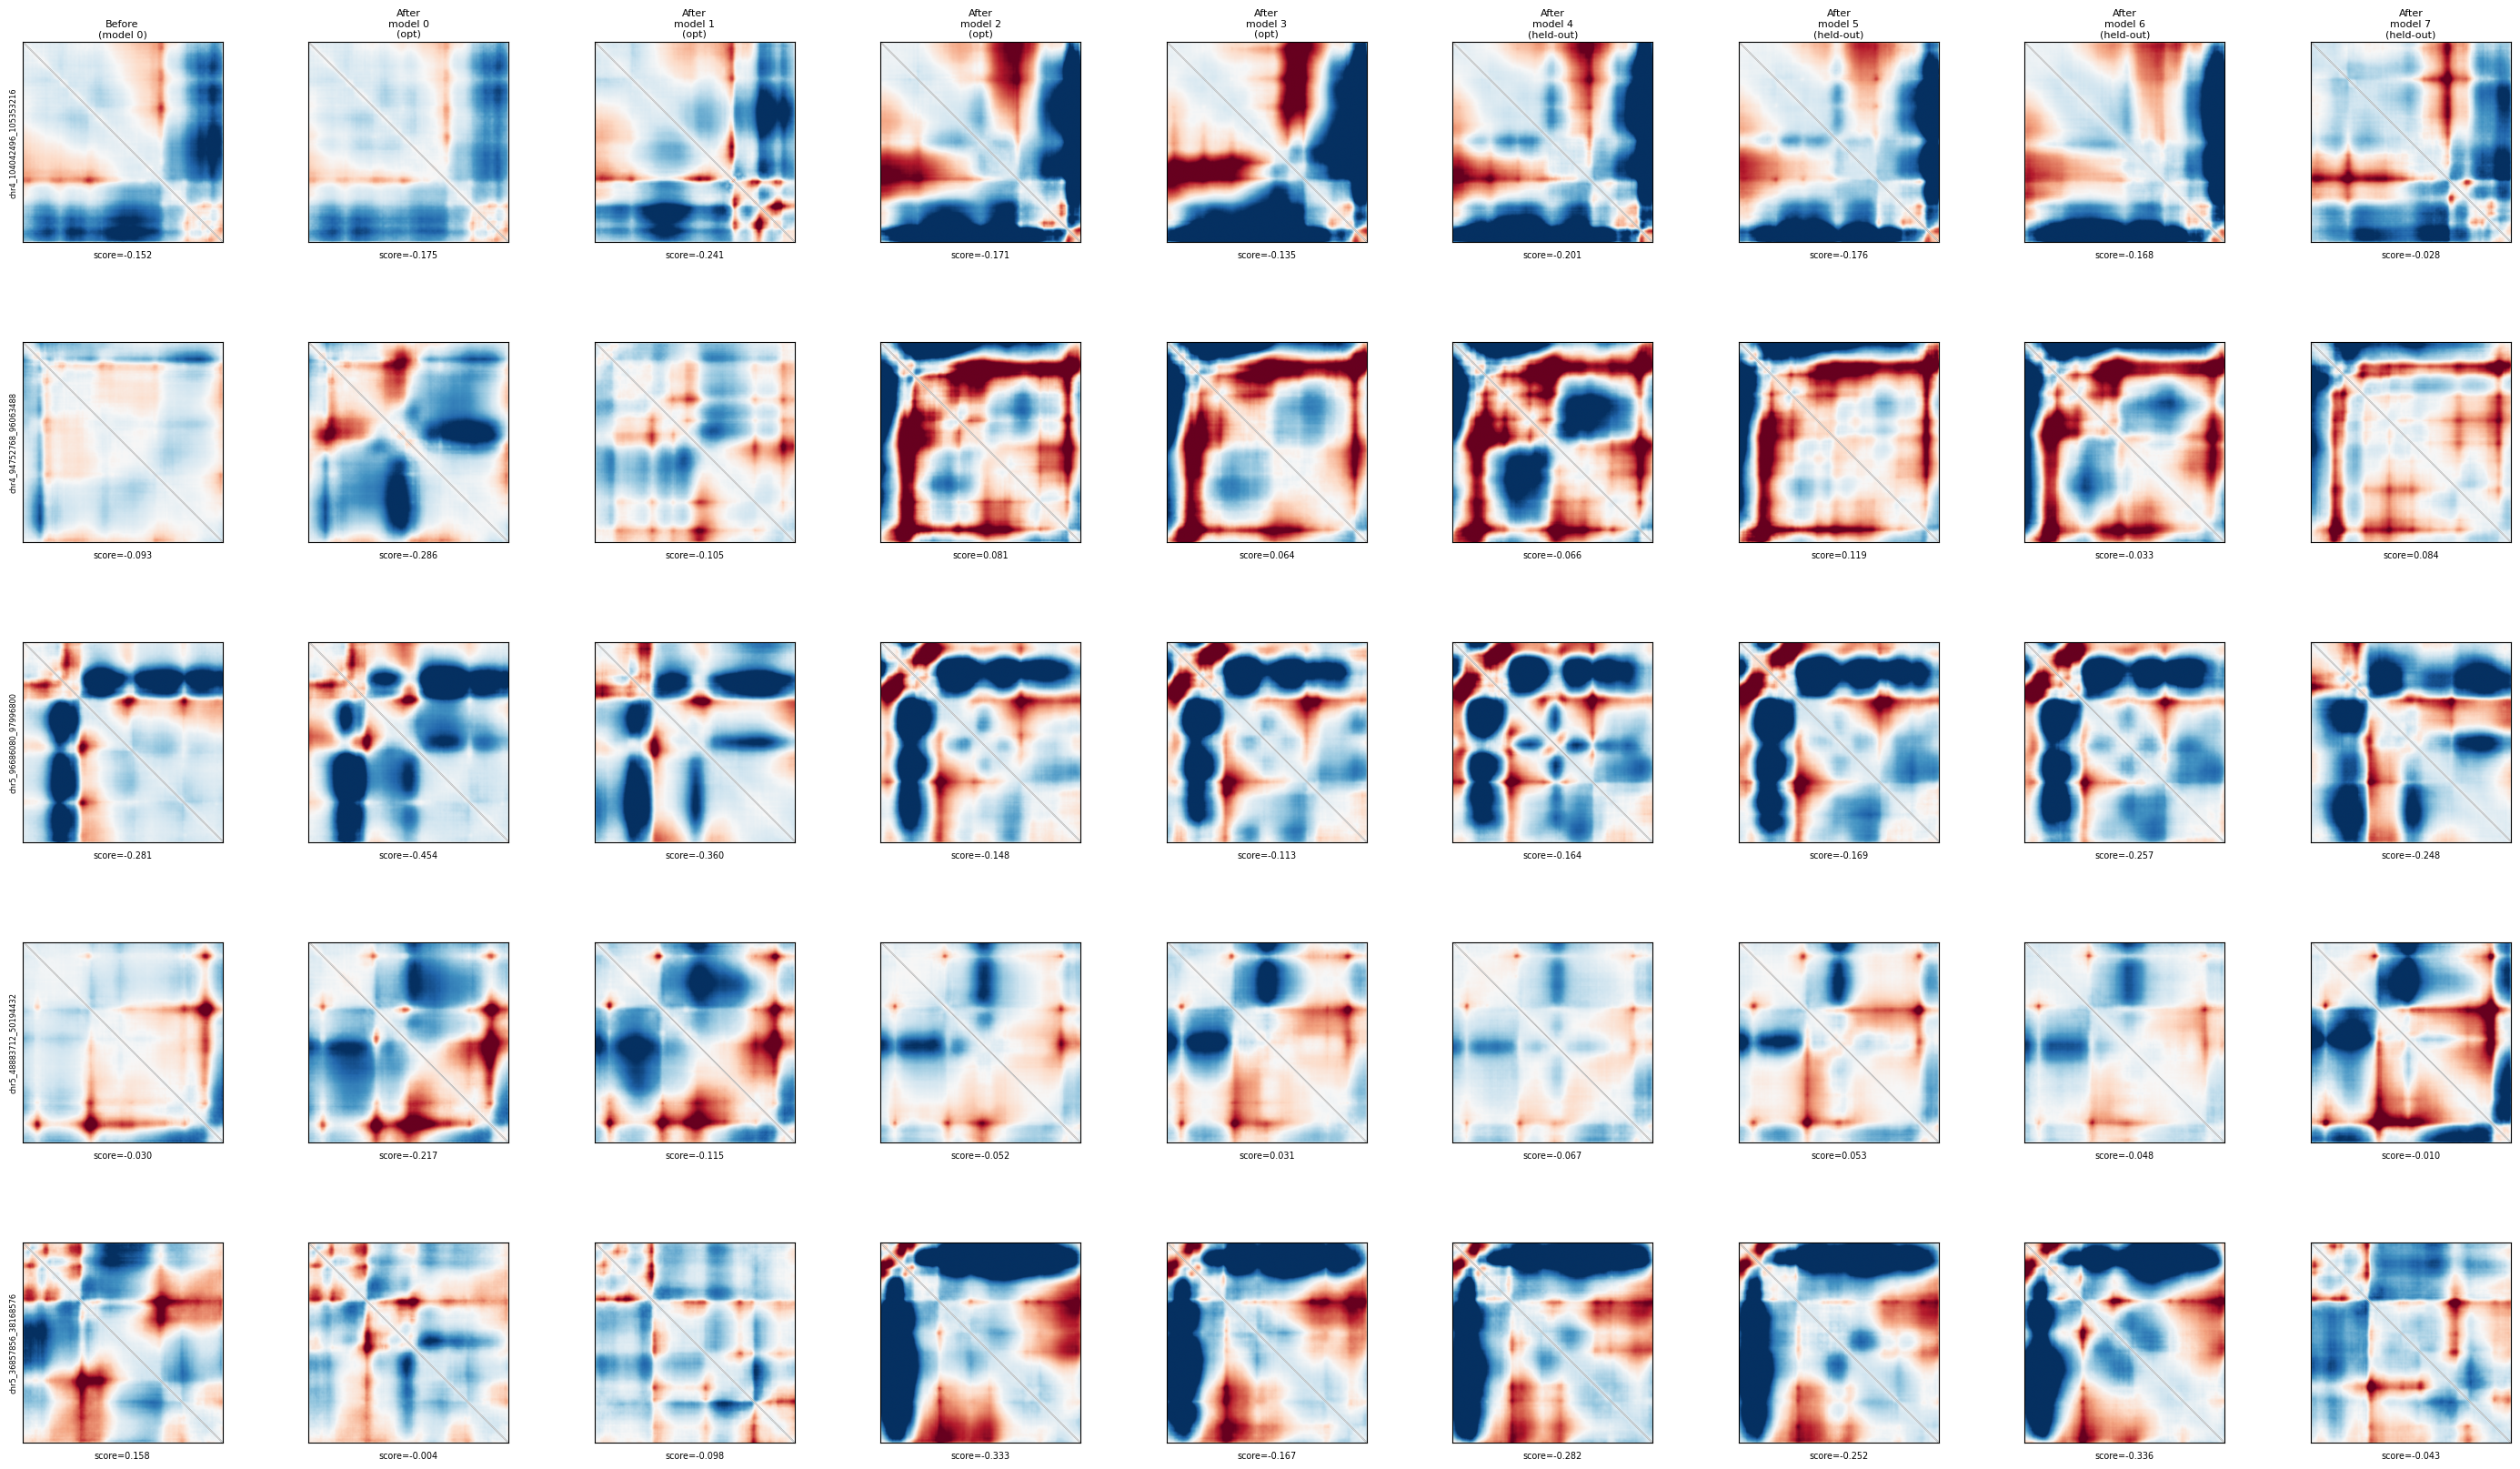

In [7]:
N_COLS   = 1 + ALL_MODELS   # before + 8 after
fig      = plt.figure(figsize=(4 * N_COLS, 4 * N_EXAMPLES))
gs_outer = gridspec.GridSpec(N_EXAMPLES, N_COLS, figure=fig,
                             hspace=0.5, wspace=0.15)

col_labels = (
    ["Before\n(model 0)"]
    + [f"After\nmodel {i}\n(opt)" for i in range(OPT_MODELS)]
    + [f"After\nmodel {i}\n(held-out)" for i in range(OPT_MODELS, ALL_MODELS)]
)

for row_idx, res in enumerate(results):
    y_before = res["y_before"]
    y_after  = res["y_after"]
    stem     = res["stem"]

    score_before = fountain_score(y_before, fountain_mask)
    maps_and_scores = [(y_before, score_before)] + [
        (y, fountain_score(y, fountain_mask)) for y in y_after
    ]

    for col_idx, (y, score) in enumerate(maps_and_scores):
        ax  = fig.add_subplot(gs_outer[row_idx, col_idx])
        mat = from_upper_triu(y.numpy(), MAP_SIZE, NUM_DIAGS)
        ax.imshow(mat, vmin=VMIN, vmax=VMAX, cmap=CMAP)
        ax.set_ylabel(stem, fontsize=6, rotation=90, labelpad=4) if col_idx == 0 else None
        ax.set_xticks([])
        ax.set_yticks([])

        if row_idx == 0:
            ax.set_title(col_labels[col_idx], fontsize=8, pad=4)

        ax.text(
            0.5, -0.04, f"score={score:.3f}",
            transform=ax.transAxes, ha='center', va='top', fontsize=7,
        )

# plt.savefig(
#     f"./../plots/fountain_examples_fold{FOLD}_{TAG}.pdf",
#     bbox_inches='tight', dpi=150,
# )
plt.show()